# Predicting Country of Origin using Product Description

Simple demo using BGE-Large embeddings via vLLM and KNN classification.

## 1. Setup and Configuration

In [1]:
!pip  install -q --upgrade pip
!pip  install -q --upgrade pandas
!pip  install -q "model-registry==0.2.15" "onnx==1.15.0" "skl2onnx==1.16.0" "onnxruntime==1.16.0" "seaborn" "openai"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
codeflare-sdk 0.29.0 requires pydantic<2, but you have pydantic 2.12.5 which is incompatible.


In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sys.path.append('../utils/')
from vllm_client import create_vllm_client, get_embeddings

In [3]:
# Configuration - your vLLM details are set via environment variables
# These are automatically configured by the workbench deployment

EMBEDDING_MODEL_ENDPOINT = os.getenv('EMBEDDING_MODEL_ENDPOINT')
EMBEDDING_MODEL_NAME = os.getenv('EMBEDDING_MODEL_NAME')
EMBEDDING_MODEL_KEY = os.getenv('EMBEDDING_MODEL_KEY')

print(f"Endpoint: {EMBEDDING_MODEL_ENDPOINT}")
print(f"Model: {EMBEDDING_MODEL_NAME}")
print(f"API Key: {'[CONFIGURED]' if EMBEDDING_MODEL_KEY else '[MISSING - set in deployment]'}")

Endpoint: https://bge-large-arrow-chatbot.apps.cluster-bw7h2.bw7h2.sandbox5279.opentlc.com
Model: bge-large
API Key: [CONFIGURED]


## 2. Load Data

In [4]:
# Load the synthetic electronics data

df = pd.read_parquet(
    "../data/prod-coo.parquet")
df.head(10)

,description,country_of_origin
0,from the coutura collection. delivering the pe...,China
1,product description by incorporating top - of ...,Vietnam
2,features : easy to blend with your outfit : ou...,China
3,xoxo was founded in 1991 as a day to evening l...,China
4,get your gowns and dresses to events in mint c...,China
5,scratch resistant mineral crystal lens and jap...,China
6,baigio men's messenger bag crossbody shoulder ...,China
7,g - shock takes performance timekeeping to the...,Thailand
8,"tommy hilfiger watches – classic, american, co...",China
9,modern style is the calling card of the mark i...,Vietnam


In [5]:
class_counts = df['country_of_origin'].value_counts().head(20)

In [6]:
valid_classes = class_counts[class_counts >= 20].index
df = df[df['country_of_origin'].isin(valid_classes)]

## 3. Connect to vLLM and Generate Embeddings

In [7]:
# Create vLLM client
client = create_vllm_client(EMBEDDING_MODEL_ENDPOINT, EMBEDDING_MODEL_NAME, EMBEDDING_MODEL_KEY)

In [8]:
# Generate embeddings for part descriptions
descriptions = df['description'].tolist()
print(f"🔄 Generating embeddings for {len(descriptions)} descriptions...")

embeddings = get_embeddings(client, descriptions, EMBEDDING_MODEL_NAME)

if embeddings:
    X = np.array(embeddings)
    print(f"✅ Generated embeddings with shape: {X.shape}")
    print(f"   - Embedding dimension: {X.shape[1]}")
else:
    print("❌ Failed to generate embeddings")
    print("Check your vLLM endpoint and API key configuration")

🔄 Generating embeddings for 3198 descriptions...
✅ Generated embeddings with shape: (3198, 1024)
   - Embedding dimension: 1024


## 4. Train KNN Classifier

In [9]:
# Prepare labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['country_of_origin'])
class_names = label_encoder.classes_

print(f"📊 Dataset info:")
print(f"   - Total samples: {len(X)}")
print(f"   - Number of countries: {len(class_names)}")
print(f"   - Countries: {list(class_names)}")

📊 Dataset info:
   - Total samples: 3198
   - Number of countries: 15
   - Countries: ['Bangladesh', 'Cambodia', 'China', 'India', 'Indonesia', 'Italy', 'Japan', 'Korea, Republic of', 'Philippines', 'Switzerland', 'Taiwan', 'Thailand', 'USA', 'United Kingdom', 'Vietnam']


In [10]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Split data: {len(X_train)} train, {len(X_test)} test")


Split data: 2238 train, 960 test


In [11]:
# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
print(f"🤖 Training KNN classifier")
knn.fit(X_train, y_train)
print("✅ KNN training complete")

🤖 Training KNN classifier
✅ KNN training complete


In [12]:
from model_registry import ModelRegistry
from model_registry.utils import S3Params
from model_registry.exceptions import StoreError

## 5. Evaluate Model

In [13]:
# Make predictions
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Model Performance:")
print(f"   - Accuracy: {accuracy:.1%}")

🎯 Model Performance:
   - Accuracy: 76.9%


In [14]:
# Show detailed results
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


📊 Detailed Classification Report:
                    precision    recall  f1-score   support

        Bangladesh       0.00      0.00      0.00         6
          Cambodia       0.36      0.31      0.33        13
             China       0.79      0.92      0.85       620
             India       0.71      0.34      0.47        29
         Indonesia       0.00      0.00      0.00         6
             Italy       0.78      0.70      0.74        10
             Japan       0.86      0.40      0.55        15
Korea, Republic of       0.50      0.17      0.25         6
       Philippines       0.75      0.43      0.55         7
       Switzerland       0.50      0.17      0.25         6
            Taiwan       0.50      0.14      0.22         7
          Thailand       0.80      0.31      0.44        13
               USA       0.77      0.61      0.68       194
    United Kingdom       1.00      0.50      0.67         6
           Vietnam       0.47      0.41      0.44        22

   

/opt/app-root/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/app-root/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/app-root/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6. Visualize Results

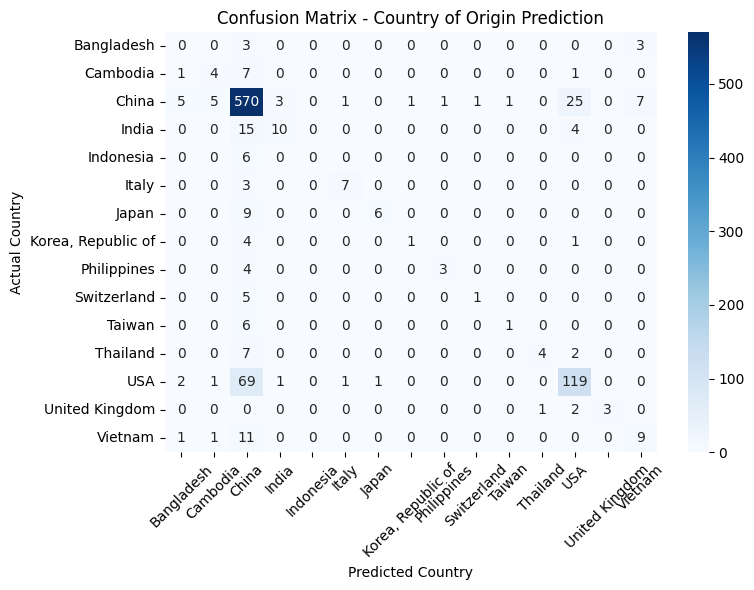

In [15]:
# Create confusion matrix
if len(class_names) > 1:
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Country of Origin Prediction')
    plt.xlabel('Predicted Country')
    plt.ylabel('Actual Country')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping confusion matrix (only one class)")

In [16]:
# Show sample predictions
print("\n🔍 Sample Predictions:")
print("=" * 80)

for i in range(min(len(X_test), 5)):
    desc = descriptions[i] if i < len(descriptions) else "Sample description"
    actual = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    
    print(f"\nSample {i+1}:")
    print(f"Description: {desc[:100]}{'...' if len(desc) > 100 else ''}")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")
    print(f"Result: {'✅ Correct' if actual == predicted else '❌ Incorrect'}")


🔍 Sample Predictions:

Sample 1:
Description: from the coutura collection. delivering the perfect blend of sport and style for those on the move, ...
Actual: China
Predicted: China
Result: ✅ Correct

Sample 2:
Description: product description by incorporating top - of - the - line materials with a weight - saving platform...
Actual: China
Predicted: China
Result: ✅ Correct

Sample 3:
Description: features : easy to blend with your outfit : our bohemia bikini bead belly chains are easy to pair wi...
Actual: China
Predicted: China
Result: ✅ Correct

Sample 4:
Description: xoxo was founded in 1991 as a day to evening lifestyle brand with attainable price points. xoxo was ...
Actual: Vietnam
Predicted: China
Result: ❌ Incorrect

Sample 5:
Description: get your gowns and dresses to events in mint condition! protect your dress with this super roomy gar...
Actual: USA
Predicted: USA
Result: ✅ Correct


## 6. Save Model

In [17]:
# Create a directory to save the model
model_dir = '../models/coo-classifier/'
os.makedirs(model_dir, exist_ok=True)

encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to: {encoder_path}")

Label encoder saved to: ../models/coo-classifier/label_encoder.pkl


In [18]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# Define input shape (1024 is your embedding dimension)
initial_type = [('float_input', FloatTensorType([None, 1024]))]

# Convert to ONNX
onnx_model = convert_sklearn(knn, initial_types=initial_type)

# Save ONNX model
onnx_path = os.path.join(model_dir, 'model.onnx')
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"✅ ONNX model saved to: {onnx_path}")

✅ ONNX model saved to: ../models/coo-classifier/model.onnx


## Summary

🎉 **Demo Complete!**

This notebook demonstrates:
- ✅ BGE-Large embeddings via vLLM API
- ✅ KNN classification for country prediction
- ✅ Model evaluation and visualization
- ✅ Real-time inference with new examples
- ✅ Convert model to ONNX and save

The model uses semantic embeddings from transformer models to understand the relationship between part descriptions and their likely countries of origin.